# Segmentasi Baris Tulisan Tangan
Ekstrak baris tulisan tangan dari foto kertas bergaris.

In [1]:
# ============================================================
# KONFIGURASI — edit bagian ini saja
# ============================================================
IMG_PATH   = "materi_2.png"      # path gambar input
OUTPUT_DIR = "dataset_asli"      # folder output

# Parameter (biasanya tidak perlu diubah)
MIN_INK     = 0.04   # sensitivitas deteksi baris (lebih kecil = lebih banyak baris)
PADDING     = 3      # pixel ekstra atas-bawah tiap crop
MIN_CC      = 2      # min. jumlah huruf per baris (filter garis kosong)
MIN_CC_AREA = 30     # min. ukuran huruf dalam pixel
# ============================================================

In [2]:
import os
import cv2
import numpy as np
from scipy.ndimage import uniform_filter1d
from scipy.signal import find_peaks, savgol_filter
import matplotlib.pyplot as plt
from IPython.display import display
import ipywidgets as widgets

print('✅ Library siap')

✅ Library siap


✅ Gambar: 721x961 px


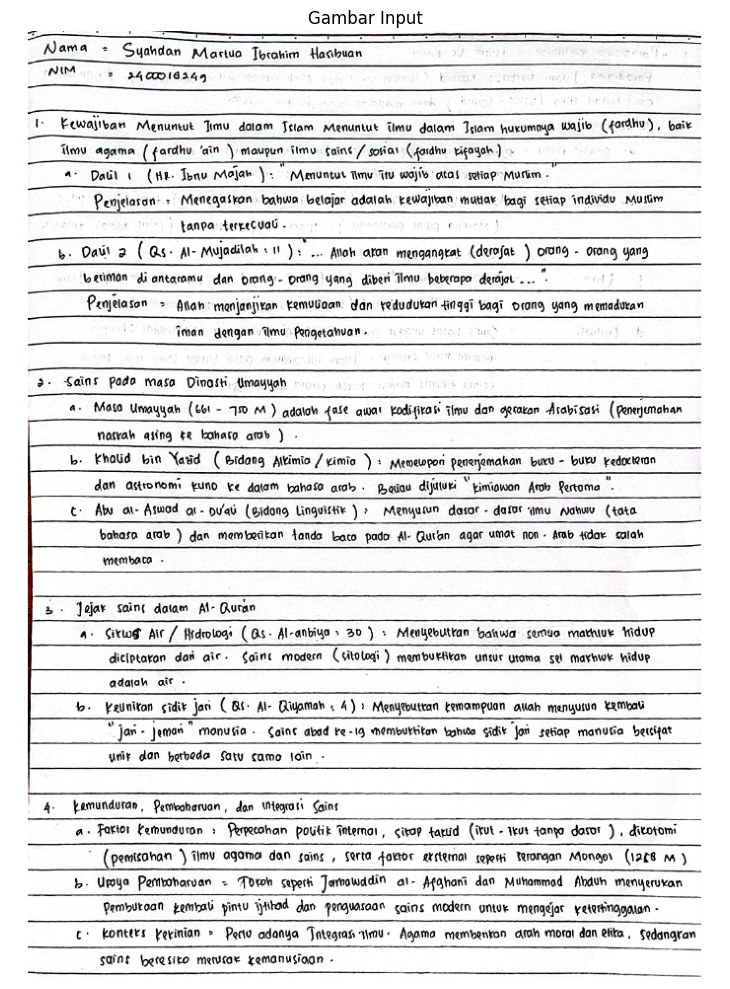

In [3]:
# ── Baca & tampilkan gambar input ──────────────────────────
img = cv2.imread(IMG_PATH)
if img is None:
    raise FileNotFoundError(f"❌ File '{IMG_PATH}' tidak ditemukan!")

H, W = img.shape[:2]
print(f'✅ Gambar: {W}x{H} px')

plt.figure(figsize=(8, 10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Gambar Input')
plt.axis('off')
plt.tight_layout()
plt.show()

In [4]:
# ── Pre-processing ─────────────────────────────────────────
gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (3, 3), 0)
binary  = cv2.adaptiveThreshold(
    blurred, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    31, 8
)

# Hapus garis horizontal kertas bergaris
kernel_line   = cv2.getStructuringElement(cv2.MORPH_RECT, (int(W * 0.65), 1))
horiz_lines   = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel_line, iterations=1)
kernel_dv     = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 3))
horiz_lines_d = cv2.dilate(horiz_lines, kernel_dv)
binary_clean  = cv2.subtract(binary, horiz_lines_d)

print('✅ Pre-processing selesai')

✅ Pre-processing selesai


📏 Estimasi tinggi baris: 17px | Puncak terdeteksi: 48


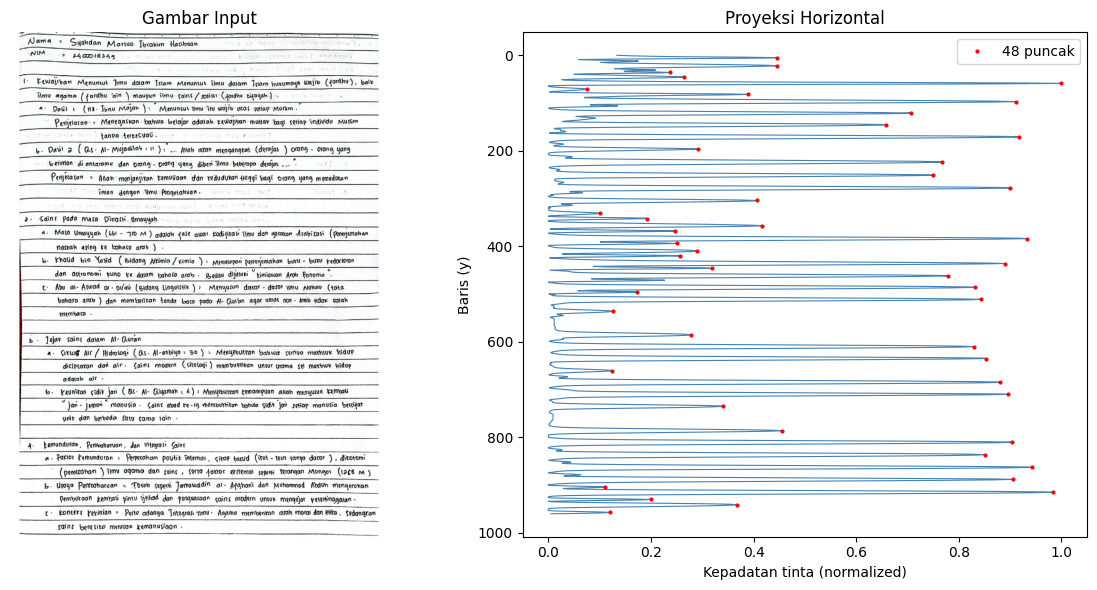

In [5]:
# ── Proyeksi horizontal + deteksi puncak baris ────────────
row_sums   = np.sum(binary_clean, axis=1) / 255.0
row_smooth = uniform_filter1d(row_sums.astype(float), size=3)
row_savgol = savgol_filter(row_smooth, window_length=7, polyorder=2)
row_savgol = np.clip(row_savgol, 0, None)
row_norm   = row_savgol / row_savgol.max()

peaks, _ = find_peaks(row_norm, height=MIN_INK, distance=10, prominence=MIN_INK)
lh = int(np.median(np.diff(peaks))) if len(peaks) >= 2 else 20
print(f'📏 Estimasi tinggi baris: {lh}px | Puncak terdeteksi: {len(peaks)}')

# Plot proyeksi
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Gambar Input'); axes[0].axis('off')
axes[1].plot(row_norm, range(len(row_norm)), linewidth=0.8, color='steelblue')
axes[1].plot(row_norm[peaks], peaks, 'r.', markersize=4, label=f'{len(peaks)} puncak')
axes[1].invert_yaxis()
axes[1].set_xlabel('Kepadatan tinta (normalized)')
axes[1].set_ylabel('Baris (y)')
axes[1].set_title('Proyeksi Horizontal')
axes[1].legend()
plt.tight_layout()
plt.show()

In [6]:
# ── Segmentasi & filter ────────────────────────────────────
separators = [0]
for i in range(len(peaks) - 1):
    seg        = row_norm[peaks[i]: peaks[i + 1]]
    valley_abs = peaks[i] + int(np.argmin(seg))
    separators.append(valley_abs)
separators.append(H - 1)

segments = []
for i in range(len(separators) - 1):
    y1, y2  = separators[i], separators[i + 1]
    seg_ink = row_sums[y1: y2 + 1]
    nonzero = np.where(seg_ink > 2)[0]
    if len(nonzero) == 0:
        continue
    ty1 = max(0,   y1 + nonzero[0]  - PADDING)
    ty2 = min(H-1, y1 + nonzero[-1] + PADDING)
    if (ty2 - ty1) < 5:
        continue
    # Filter connected component
    crop_bin   = binary_clean[ty1: ty2 + 1, :]
    num_labels, _, stats, _ = cv2.connectedComponentsWithStats(crop_bin, connectivity=8)
    big_cc = sum(1 for j in range(1, num_labels) if stats[j, cv2.CC_STAT_AREA] >= MIN_CC_AREA)
    if big_cc >= MIN_CC:
        segments.append((ty1, ty2))

print(f'✅ {len(segments)} baris terdeteksi')

✅ 39 baris terdeteksi


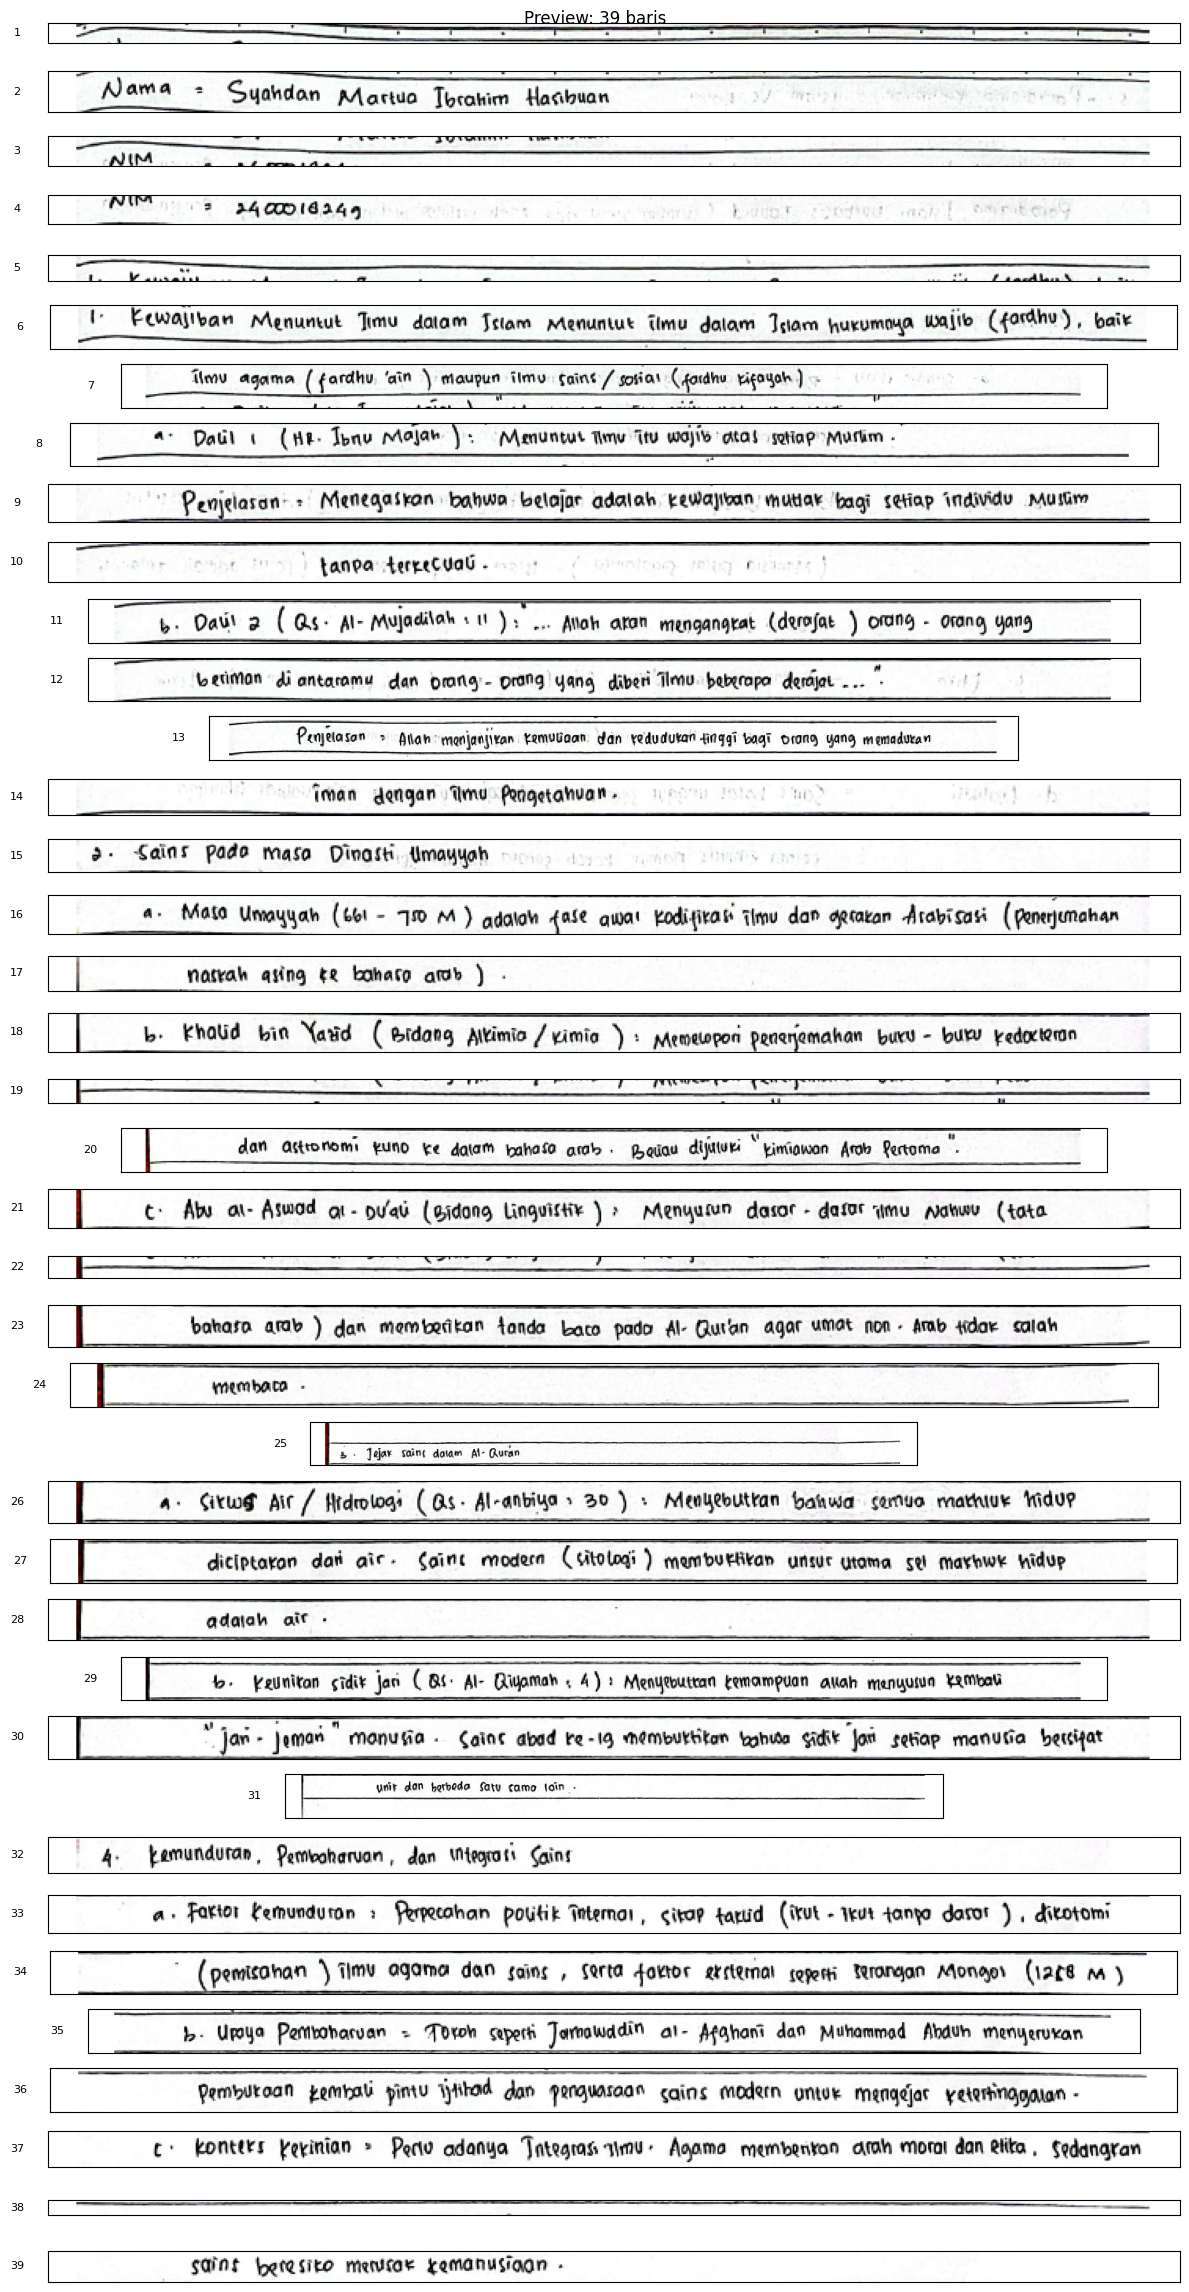

In [7]:
# ── Preview semua hasil crop ───────────────────────────────
n = len(segments)
fig, axes = plt.subplots(n, 1, figsize=(12, n * 0.6))
if n == 1: axes = [axes]

for i, (ax, (y1, y2)) in enumerate(zip(axes, segments)):
    crop = img[y1: y2+1, :, :]
    ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    ax.set_ylabel(f'{i+1}', fontsize=8, rotation=0, labelpad=22, va='center')
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle(f'Preview: {n} baris', fontsize=12)
plt.tight_layout()
plt.show()

In [8]:
# ── Simpan semua crop ──────────────────────────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)

for idx, (y1, y2) in enumerate(segments):
    crop     = img[y1: y2+1, :, :]
    filename = os.path.join(OUTPUT_DIR, f'{idx+1:03d}.png')
    cv2.imwrite(filename, crop)

print(f'🎉 Selesai! {len(segments)} baris disimpan ke folder "{OUTPUT_DIR}/"')

🎉 Selesai! 39 baris disimpan ke folder "dataset_asli/"
